# Phase 1 Analysis — 按中期报告 Table 4.1 整理

阅读顺序：**Effectiveness → Efficiency → Maintainability → Questionnaire**。
每个结果维度依次展示参与者数据、描述统计、组间比较、图表和相关敏感性分析。
分析范围是 Phase 1 的 14 名参与者（AI 6、Manual 8）。

| Table 4.1 维度 | 本 notebook 的指标顺序 |
|---|---|
| Effectiveness | Syntax / Runtime / Function Error Rate；Branch / Statement Coverage；Mutation Score；Assertion Score |
| Efficiency | Generation / Execution Time；Generation Efficiency（Branch / Statement / Mutation）；Execution Efficiency（Branch / Statement / Mutation） |
| Maintainability | Test Smell Density；smell 类型数量作为描述性补充 |
| Questionnaire | Pre-survey 背景摘要；AI 和 Manual post-survey 分开展示；开放式回答编码表 |

**运行方式：**从上到下运行。默认从 `results/phase1/` 重算统计结果。
缺失的 mutation CSV 已从汇总 Excel 的原有 `Mutation score` 存档工作表恢复，
恢复说明在 CSV 同目录的 `RESTORATION.md`，没有重新运行 mutation 实验。
将 `REBUILD_FROM_RAW` 改为 `False` 可仅展示已保存的统计表。
新图表保存到 `outputs/figures/table41/`，与旧 notebook 的图表分开。

**个体图展示规则：**6 号 not usable，从参与者点图中隐藏；统计分析仍保留完整样本。
个体图中的均值/中位数也基于展示子集，不能当作完整样本统计表的均值。
差异区间图保留完整统计样本；问卷按原始有效回答汇总。
**8 号人工复核：**`test_file` 已确认为 non-trivial assertion，score = 1，
uncertain count = 0，因此移除 assertion 编码敏感性分析。

**统计约定：**差异均为 AI − Manual；三个预设主要结局分别是 adjusted mutation
score、mutation generation efficiency 和 test smell density，Holm 校正保持同一检验族，
不随章节划分改变。其他检验为探索性。置信区间使用 20,000 次组内 bootstrap。
缺失值保留为 NA；调整后的 mutation score 来自等价变异体抽样复核估计。

## 0. 运行准备与数据来源

本节只准备共享数据和绘图工具，四个内容章节从下方开始。

In [1]:
from pathlib import Path
from textwrap import fill
import os
import sys

# Keep Matplotlib's cache inside the analysis output directory so the notebook is
# reproducible in local, CI, and sandboxed environments.
ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / "analysis_utils.py").exists():
    ANALYSIS_DIR = Path.cwd() / "scripts" / "phase1_analysis"
os.environ.setdefault("MPLCONFIGDIR", str(ANALYSIS_DIR / "outputs" / ".matplotlib-cache"))
sys.path.insert(0, str(ANALYSIS_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analysis_utils import all_metric_metadata
from config import FIGURE_DIR as BASE_FIGURE_DIR, TABLE_DIR, RESULTS_DIR, GROUP_COLORS, GROUP_ORDER, PRIMARY_METRICS
from IPython.display import display

FIGURE_DIR = BASE_FIGURE_DIR / 'table41'
from run_analysis import run

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# One restrained, color-blind-friendly visual style is used for every figure.
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9.5,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.22,
    "legend.frameon": False, "figure.dpi": 150, "savefig.dpi": 300,
})

def save_figure(fig, filename: str) -> None:
    # Save one figure as draft-friendly PNG and editable vector SVG.
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.svg", bbox_inches="tight")

def display_values(values: pd.Series, scale: str) -> pd.Series:
    # Convert 0-1 proportions to percentages for display only.
    return values * 100 if scale == "proportion" else values

def format_metric_axis(ax, scale: str) -> None:
    # Label the vertical axis using the metric's documented unit.
    if scale == "proportion":
        ax.set_ylabel("Percent")
        ax.set_ylim(bottom=0)
    elif scale == "seconds":
        ax.set_ylabel("Seconds")
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylabel("Per second")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

def participant_dot_panel(ax, data, metric: str, metadata: dict) -> None:
    # Draw raw participant values plus group mean and median.
    scale = str(metadata["scale"])
    for x_position, group in enumerate(GROUP_ORDER):
        subset = data.loc[
            data["group"].eq(group) & data[metric].notna(),
            ["participant_number", metric],
        ].sort_values("participant_number")
        values = display_values(subset[metric].astype(float), scale)
        # Deterministic offsets reveal ties without adding randomness or implying
        # additional measurement precision.
        offsets = np.linspace(-0.09, 0.09, max(len(values), 1))
        ax.scatter(
            np.full(len(values), x_position) + offsets, values, s=34,
            color=GROUP_COLORS[group], edgecolor="white", linewidth=0.6,
            alpha=0.9, zorder=3,
        )
        if not values.empty:
            ax.scatter(
                x_position, values.mean(), marker="D", s=58,
                facecolor="white", edgecolor=GROUP_COLORS[group],
                linewidth=1.5, zorder=4,
            )
            ax.hlines(
                values.median(), x_position - 0.16, x_position + 0.16,
                color=GROUP_COLORS[group], linewidth=2.0, zorder=2,
            )
    ax.set_xticks(range(len(GROUP_ORDER)), GROUP_ORDER)
    ax.set_title(fill(str(metadata.get("short_label", metadata["label"])), width=30))
    format_metric_axis(ax, scale)

In [2]:
# False：展示已有统计快照。True：从完整的 Phase 1 原始数据重新计算。
REBUILD_FROM_RAW = True
if REBUILD_FROM_RAW:
    from run_analysis import SOURCE_FILES
    missing_sources = [str(RESULTS_DIR / name) for name in SOURCE_FILES
                       if not (RESULTS_DIR / name).is_file()]
    if missing_sources:
        raise FileNotFoundError("原始数据尚未齐备，无法重新计算：\n" + "\n".join(missing_sources))
    run()

# 两种模式都读取同一套输出结构，明确区分计算来源。
participants = pd.read_csv(TABLE_DIR / "participant_master.csv")
# 展示排除与统计排除不同：这里仅隐藏个体图中的 6 号。
plot_participants = participants.loc[participants["participant_number"].ne(6)].copy()
descriptive = pd.read_csv(TABLE_DIR / "descriptive_statistics.csv")
primary = pd.read_csv(TABLE_DIR / "primary_results.csv")
secondary = pd.read_csv(TABLE_DIR / "secondary_results.csv")
sensitivity = pd.read_csv(TABLE_DIR / "sensitivity_results.csv")
likert = pd.read_csv(TABLE_DIR / "questionnaire_likert.csv")
baseline = pd.read_csv(TABLE_DIR / "questionnaire_baseline.csv")
open_text = pd.read_csv(TABLE_DIR / "questionnaire_open_text_coding.csv")
validation = pd.read_csv(TABLE_DIR / "data_validation.csv")
print("数据模式：", "已从原始数据重新计算" if REBUILD_FROM_RAW else "已保存的统计快照（未重新计算）")
print("Phase 1 原始数据目录：", RESULTS_DIR)
print("图表输出目录：", FIGURE_DIR)
print("样本数：", participants.groupby("group").size().to_dict())
# 此处展示的是快照生成时的核验，不代表再次核验当前原始文件。
display(validation)
display(pd.read_csv(TABLE_DIR / "data_completeness.csv"))

数据模式： 已从原始数据重新计算
Phase 1 原始数据目录： /Users/ruoyur/.codex/worktrees/99b4/markdown-it-py/results/phase1
图表输出目录： /Users/ruoyur/.codex/worktrees/99b4/markdown-it-py/scripts/phase1_analysis/outputs/figures/table41
样本数： {'AI': 6, 'Manual': 8}


,check,status,detail
0,Allocated participant IDs,PASS,Expected IDs 1-16 exactly once.
1,Participation count,PASS,Observed 14 participants.
2,Treatment group counts,PASS,"Observed {'Manual': 8, 'AI': 6}."
3,Non-participant IDs,PASS,"Observed [13, 15]."
4,Error-rate count invariant,PASS,valid + syntax + runtime + function errors equ...
5,No-valid-test participants,PASS,"Observed [4, 6]."
6,Missingness: participant_statement_coverage,PASS,"Missing for participant IDs [4, 6]."
7,Missingness: assertion_score,PASS,"Missing for participant IDs [4, 6]."
8,Missingness: execution_time_seconds,PASS,"Missing for participant IDs [4, 6]."
9,Missingness: test_smell_density,PASS,"Missing for participant IDs [4, 6]."


,metric,label,available_n,ai_n,manual_n,missing_participant_ids
0,specified_estimated_adjusted_mutation_score,Estimated adjusted mutation score,14,6,8,NaN
1,mutation_generation_efficiency_per_second,Mutation generation efficiency (score per second),14,6,8,NaN
2,test_smell_density,Test smell density,12,6,6,"4,6"
3,syntax_error_rate,Syntax error rate,14,6,8,NaN
4,runtime_error_rate,Runtime error rate,14,6,8,NaN
5,function_error_rate,Function error rate,14,6,8,NaN
6,participant_statement_coverage,Statement coverage,12,6,6,"4,6"
7,participant_branch_coverage,Branch coverage,12,6,6,"4,6"
8,assertion_score,Assertion score,12,6,6,"4,6"
9,generation_time_seconds,Generation time (seconds),14,6,8,NaN


In [3]:
# Table 4.1 的内容顺序与 SAP 的主要/次要统计角色是两个独立分类。
EFFECTIVENESS_METRICS = [
    "syntax_error_rate", "runtime_error_rate", "function_error_rate",
    "participant_branch_coverage", "participant_statement_coverage",
    "specified_estimated_adjusted_mutation_score", "assertion_score",
]
EFFICIENCY_METRICS = [
    "generation_time_seconds", "execution_time_seconds",
    "branch_generation_efficiency_per_second", "statement_generation_efficiency_per_second",
    "mutation_generation_efficiency_per_second",
    "branch_execution_efficiency_per_second", "statement_execution_efficiency_per_second",
    "mutation_execution_efficiency_per_second",
]
MAINTAINABILITY_METRICS = ["test_smell_density"]
metric_metadata = all_metric_metadata()
results = pd.concat([
    primary.assign(analysis_role="Primary"),
    secondary.assign(analysis_role="Exploratory"),
], ignore_index=True)
result_columns = [
    "label", "analysis_role", "n_ai", "n_manual", "mean_ai", "mean_manual",
    "mean_difference_ai_minus_manual", "bootstrap_ci95_lower", "bootstrap_ci95_upper",
    "cliffs_delta", "exact_permutation_p_value", "holm_adjusted_p_value", "scale",
]

def ordered_results(metrics: list) -> pd.DataFrame:
    # 明确按论文指标顺序排列，而不是按 CSV 中主要/次要顺序排列。
    return results.set_index("metric").loc[metrics, result_columns].reset_index()

def sensitivity_for(metrics: list) -> pd.DataFrame:
    return sensitivity.loc[sensitivity["metric"].isin(metrics)].copy()

## 1. Effectiveness — 测试有效性

按 Table 4.1 整理三种错误率、branch/statement coverage、mutation score 和 assertion score。
错误率反映全部提交测试的错误负担；coverage 和 assertion 只对有效测试计算。
参与者 4、6 无有效测试，其 coverage/assertion 为 NA，mutation score 保留采集结果。
比例数据表使用 0–1，图中转换为百分比。Mutation score 为此维度的预设主要结局。

In [4]:
# 按 Table 4.1 顺序展示参与者数据；NA 保留为缺失，不能当成零。
effectiveness_data = participants[["participant_number", "group", "valid_test_count", *EFFECTIVENESS_METRICS]].copy()
display(effectiveness_data)
# 同一维度内先看描述统计，再看组间比较；保留主要/探索性角色。
display(descriptive.loc[descriptive["metric"].isin(EFFECTIVENESS_METRICS)])
display(ordered_results(EFFECTIVENESS_METRICS))

,participant_number,group,valid_test_count,syntax_error_rate,runtime_error_rate,function_error_rate,participant_branch_coverage,participant_statement_coverage,specified_estimated_adjusted_mutation_score,assertion_score
0,1,Manual,5.0,0.0,0.0,0.00,0.625189,0.719699,0.683745,1.000000
1,2,AI,5.0,0.0,0.0,0.00,0.625189,0.719699,0.688043,1.000000
2,3,AI,5.0,0.0,0.0,0.00,0.625189,0.719699,0.691334,1.000000
3,4,Manual,0.0,0.8,0.2,0.00,NaN,NaN,0.000000,NaN
4,5,Manual,5.0,0.0,0.0,0.00,0.623680,0.714782,0.686862,0.600000
5,6,Manual,0.0,0.0,1.0,0.00,NaN,NaN,0.000000,NaN
6,7,AI,5.0,0.0,0.0,0.00,0.625943,0.719988,0.692502,1.000000
7,8,Manual,1.0,0.0,0.0,0.50,0.388386,0.574197,0.406438,1.000000
8,9,Manual,3.0,0.0,0.4,0.00,0.124434,0.330633,0.080550,0.000000
9,10,AI,5.0,0.0,0.0,0.00,0.625943,0.719988,0.689208,1.000000


,metric,group,n,mean,standard_deviation,median,first_quartile,third_quartile,minimum,maximum
0,specified_estimated_adjusted_mutation_score,AI,6,0.690853,0.001854,0.691334,0.689740,0.692210,0.688043,0.692695
1,specified_estimated_adjusted_mutation_score,Manual,8,0.348382,0.287218,0.409350,0.060412,0.558833,0.000000,0.686862
6,syntax_error_rate,AI,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,syntax_error_rate,Manual,8,0.100000,0.282843,0.000000,0.000000,0.000000,0.000000,0.800000
8,runtime_error_rate,AI,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,runtime_error_rate,Manual,8,0.225000,0.345378,0.100000,0.000000,0.250000,0.000000,1.000000
10,function_error_rate,AI,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,function_error_rate,Manual,8,0.093750,0.186006,0.000000,0.000000,0.062500,0.000000,0.500000
12,participant_statement_coverage,AI,6,0.719795,0.000149,0.719699,0.719699,0.719916,0.719699,0.719988
13,participant_statement_coverage,Manual,6,0.605486,0.151425,0.645936,0.574920,0.716083,0.330633,0.719699


,metric,label,analysis_role,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,holm_adjusted_p_value,scale
0,syntax_error_rate,Syntax error rate,Exploratory,6,8,0.000000,0.100000,-0.100000,-0.300000,0.000000,-0.125000,1.000000,NaN,proportion
1,runtime_error_rate,Runtime error rate,Exploratory,6,8,0.000000,0.225000,-0.225000,-0.475000,-0.050000,-0.500000,0.164835,NaN,proportion
2,function_error_rate,Function error rate,Exploratory,6,8,0.000000,0.093750,-0.093750,-0.218750,0.000000,-0.250000,0.472527,NaN,proportion
3,participant_branch_coverage,Branch coverage,Exploratory,6,6,0.625440,0.463047,0.162394,0.039719,0.328181,0.888889,0.010823,NaN,proportion
4,participant_statement_coverage,Statement coverage,Exploratory,6,6,0.719795,0.605486,0.114309,0.025504,0.242553,0.888889,0.010823,NaN,proportion
5,specified_estimated_adjusted_mutation_score,Estimated adjusted mutation score,Primary,6,8,0.690853,0.348382,0.342471,0.160589,0.531443,1.000000,0.008658,0.012987,proportion
6,assertion_score,Assertion score,Exploratory,6,6,1.000000,0.627778,0.372222,0.122222,0.650000,0.666667,0.060606,NaN,proportion


### 图 1. Effectiveness 个体分布

每点代表一位参与者；空心菱形为均值，横线为中位数。七个指标使用独立纵轴。

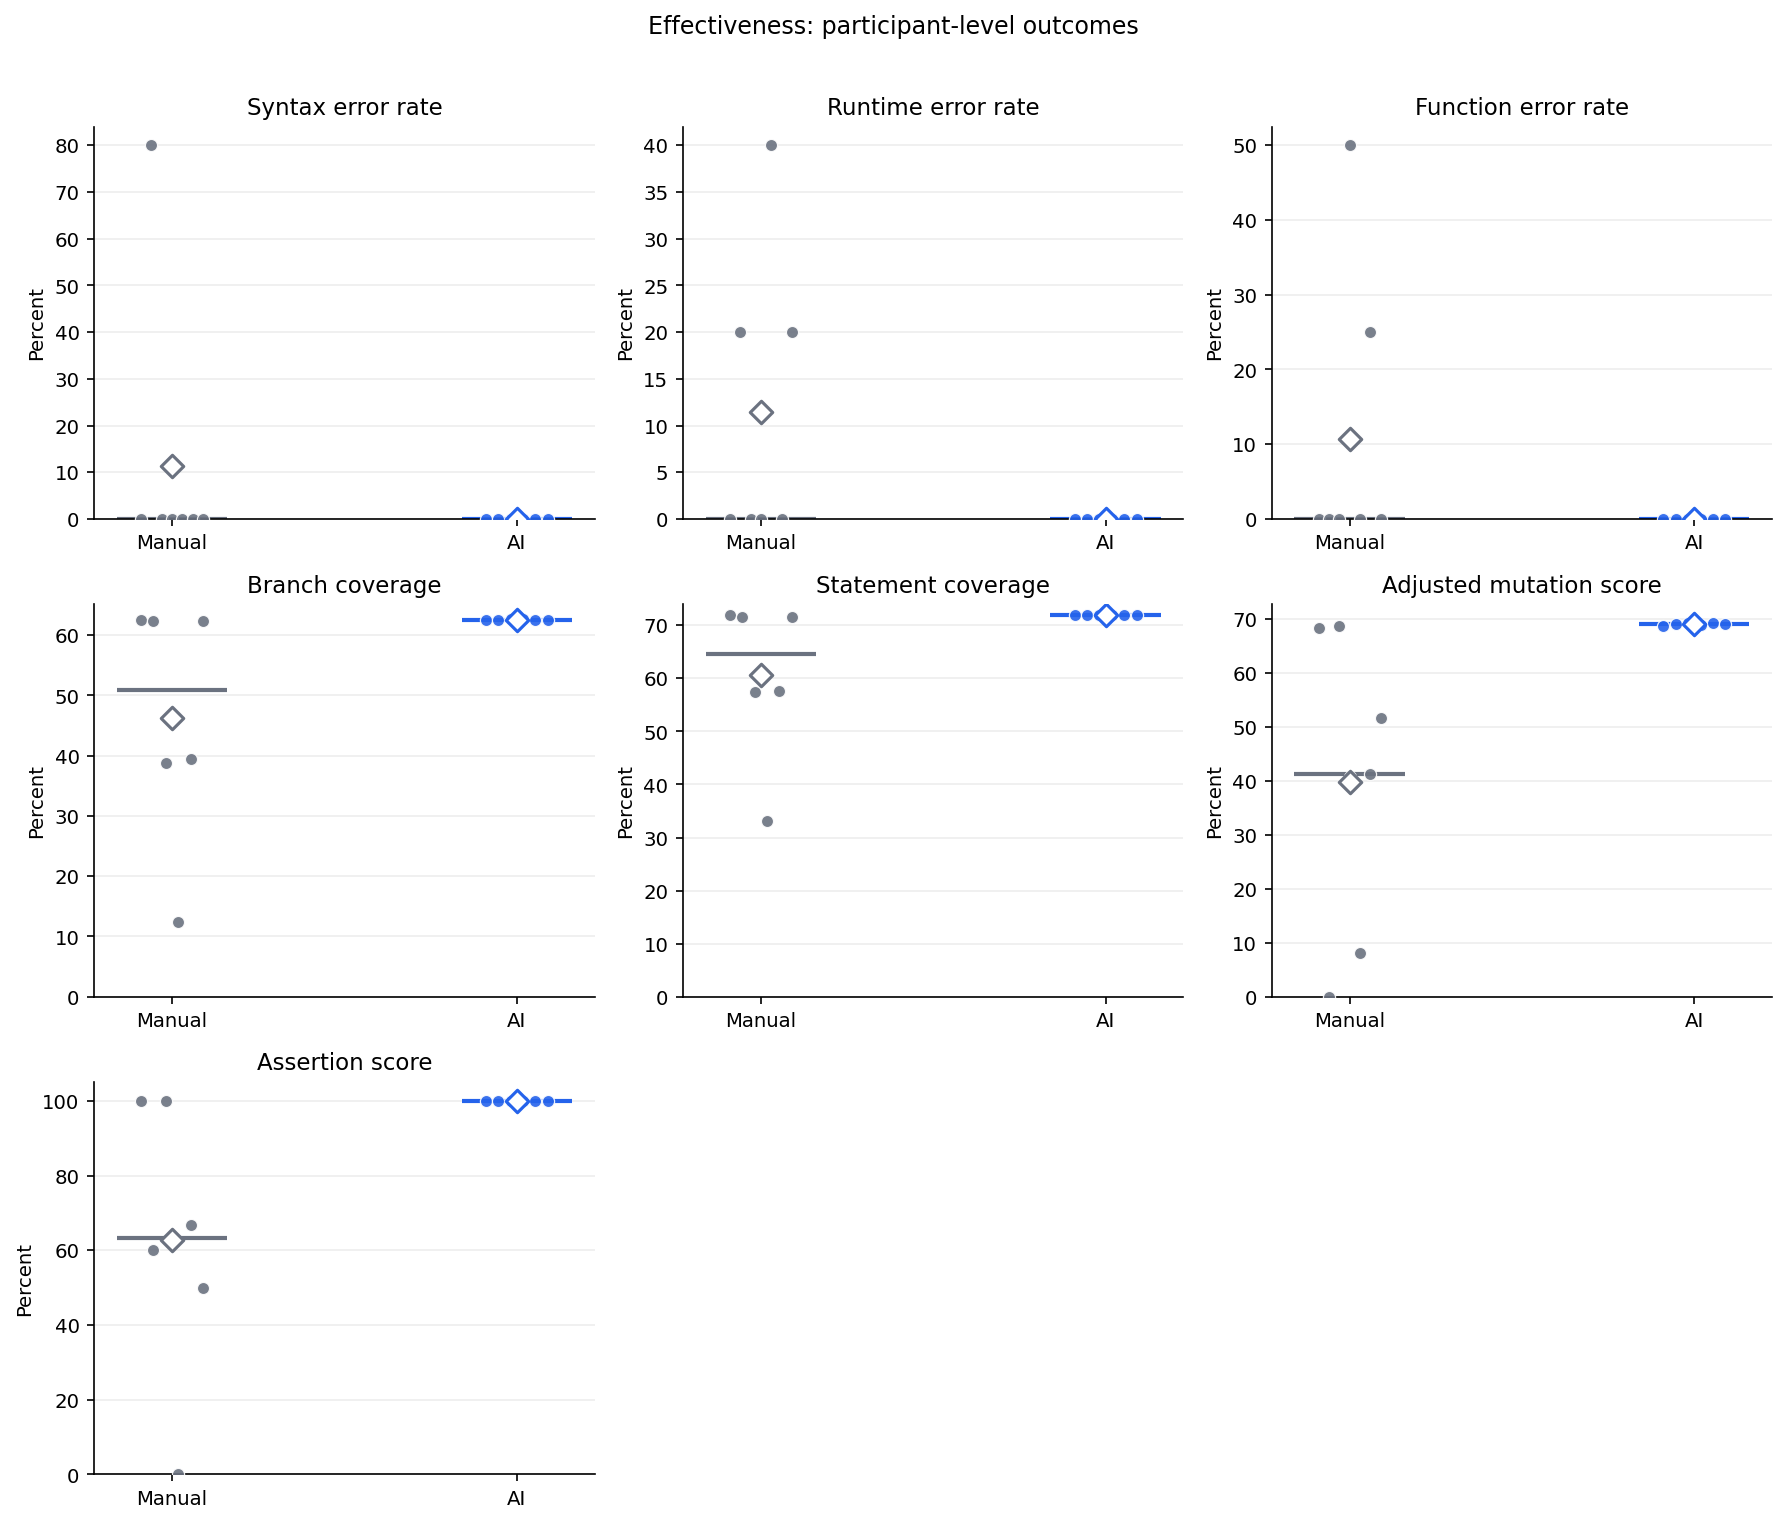

In [5]:
# 七个有效性指标全部展示，按 Table 4.1 排序；最后一个空面板关闭。
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, metric in zip(axes.flat, EFFECTIVENESS_METRICS):
    participant_dot_panel(ax, plot_participants, metric, metric_metadata[metric])
for ax in list(axes.flat)[len(EFFECTIVENESS_METRICS):]:
    ax.set_visible(False)
fig.suptitle("Effectiveness: participant-level outcomes", y=1.01)
fig.tight_layout()
save_figure(fig, "effectiveness_outcomes")
plt.show()
plt.close(fig)

### 组间差异与不确定性

蓝点为 AI − Manual 均值差，横线为 95% bootstrap 区间。点上方标注估计值，两端下方标注下限和上限。每个指标使用独立横轴；百分比指标转换为百分点。此图使用统计表的完整样本（含 6 号），与隐藏 6 号的个体图不同。Holm 校正仍针对跨维度的三个预设主要结局。

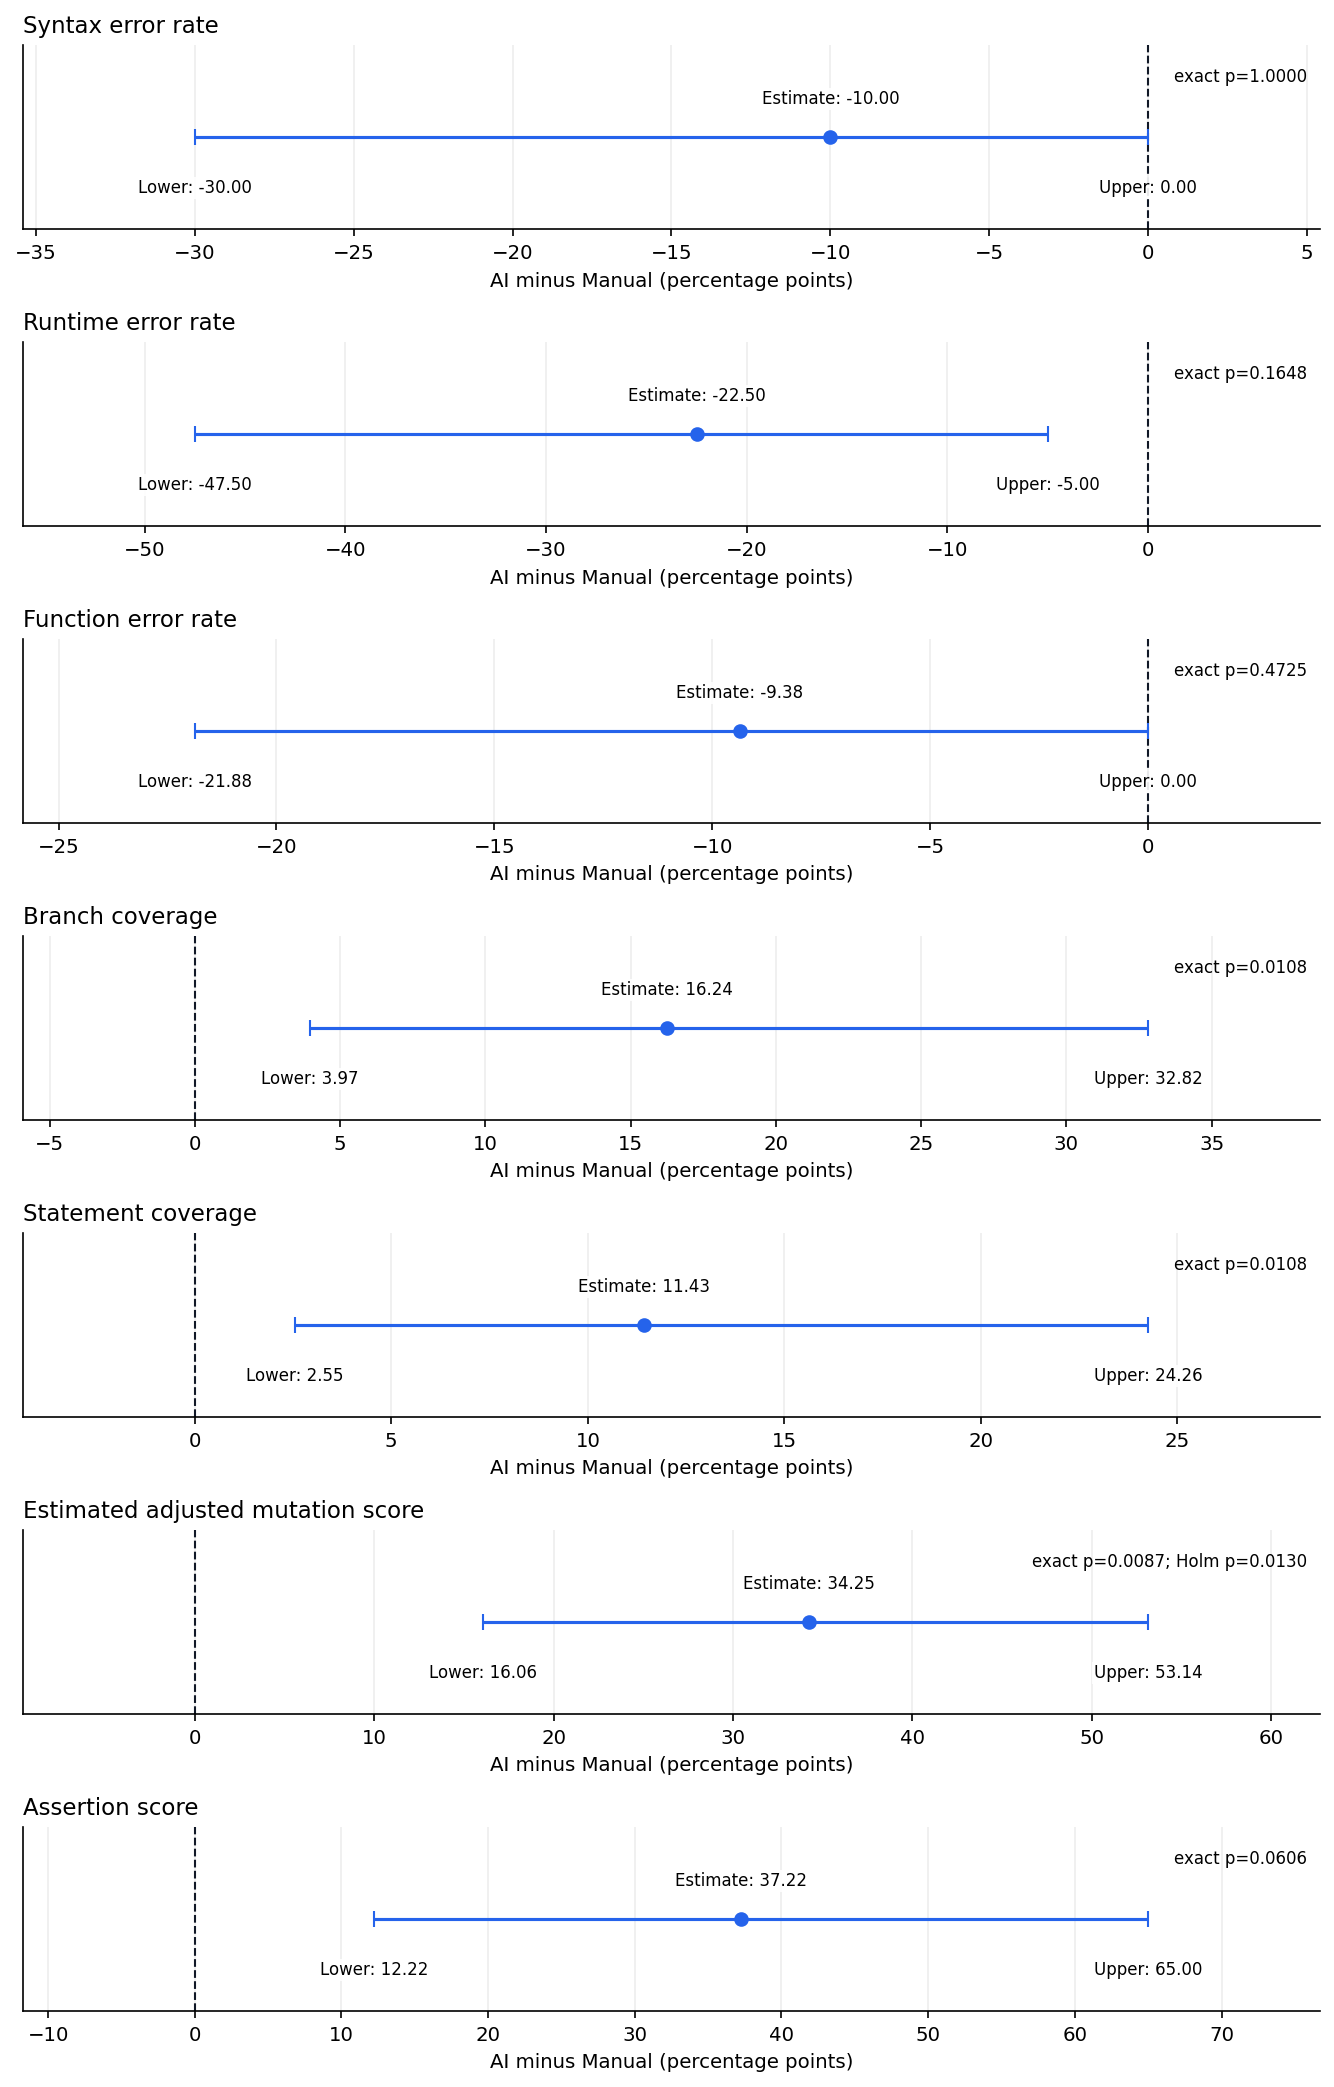

In [6]:
# 独立坐标轴避免比例、秒和每秒速率混在同一尺度。
rows = ordered_results(EFFECTIVENESS_METRICS)
fig, axes = plt.subplots(len(rows), 1, figsize=(9, 2.0 * len(rows)), squeeze=False)
for ax, (_, row) in zip(axes.flat, rows.iterrows()):
    multiplier = 100.0 if row["scale"] == "proportion" else 1.0
    estimate = row["mean_difference_ai_minus_manual"] * multiplier
    lower = row["bootstrap_ci95_lower"] * multiplier
    upper = row["bootstrap_ci95_upper"] * multiplier
    ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
    ax.errorbar(estimate, 0, xerr=[[estimate - lower], [upper - estimate]],
                fmt="o", color=GROUP_COLORS["AI"], capsize=4)
    # 数字跟随其实际横坐标，估计值置于上方，两个端点置于下方。
    number = lambda value: f"{value:.3g}" if 0 < abs(value) < 0.01 else f"{value:.2f}"
    for value, label, offset in [(estimate, "Estimate", 14), (lower, "Lower", -20), (upper, "Upper", -20)]:
        ax.annotate(f"{label}: {number(value)}", (value, 0),
                    xytext=(0, offset), textcoords="offset points", ha="center",
                    va="bottom" if offset > 0 else "top", fontsize=8,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1))
    ax.set_ylim(-1, 1)
    ax.margins(x=0.18)
    ax.set_yticks([])
    ax.set_title(str(row["label"]), loc="left")
    unit = {"proportion": "percentage points", "seconds": "seconds", "rate": "per second"}[row["scale"]]
    ax.set_xlabel(f"AI minus Manual ({unit})")
    p_text = f"exact p={row['exact_permutation_p_value']:.4f}"
    if pd.notna(row["holm_adjusted_p_value"]):
        p_text += f"; Holm p={row['holm_adjusted_p_value']:.4f}"
    ax.text(0.99, 0.8, p_text, transform=ax.transAxes, ha="right", fontsize=8)
    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "effectiveness_difference_intervals")
plt.show()
plt.close(fig)

### Effectiveness 敏感性分析

比较 raw/adjusted mutation score。8 号 assertion 已完成复核，不再比较替代编码。

In [7]:
display(sensitivity_for(EFFECTIVENESS_METRICS + ["specified_raw_mutation_score"]))

,scenario,metric,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,permutation_allocations
0,Primary adjusted mutation score,specified_estimated_adjusted_mutation_score,6,8,0.690853,0.348382,0.342471,0.159515,0.528386,1.0,0.008658,3003
1,Raw mutation score,specified_raw_mutation_score,6,8,0.658328,0.332024,0.326304,0.151813,0.506028,1.0,0.008658,3003


## 2. Efficiency — 测试效率

先展示生成/执行时间，再展示三种生成效率和三种执行效率，与 Table 4.1 一致。
效率 = 有效性分数 ÷ 时间（秒），不是测试数量 ÷ 时间。
mutation generation efficiency 是预设主要结局，其他效率指标为探索性。
时间表保留秒；关系图将生成时间转换为分钟。效率图保留每秒速率。

In [8]:
# 按 Table 4.1 顺序展示参与者数据；NA 保留为缺失，不能当成零。
efficiency_data = participants[["participant_number", "group", "valid_test_count", *EFFICIENCY_METRICS]].copy()
display(efficiency_data)
# 同一维度内先看描述统计，再看组间比较；保留主要/探索性角色。
display(descriptive.loc[descriptive["metric"].isin(EFFICIENCY_METRICS)])
display(ordered_results(EFFICIENCY_METRICS))

,participant_number,group,valid_test_count,generation_time_seconds,execution_time_seconds,branch_generation_efficiency_per_second,statement_generation_efficiency_per_second,mutation_generation_efficiency_per_second,branch_execution_efficiency_per_second,statement_execution_efficiency_per_second,mutation_execution_efficiency_per_second
0,1,Manual,5.0,3337.0,0.217666,0.000187,0.000216,0.000205,2.872236,3.306432,3.141251
1,2,AI,5.0,1462.0,0.223280,0.000428,0.000492,0.000471,2.800021,3.223301,3.081522
2,3,AI,5.0,2105.0,0.223848,0.000297,0.000342,0.000328,2.792921,3.215128,3.088413
3,4,Manual,0.0,5400.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
4,5,Manual,5.0,4124.0,0.386794,0.000151,0.000173,0.000167,1.612434,1.847965,1.775782
5,6,Manual,0.0,3600.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
6,7,AI,5.0,1490.0,0.219933,0.000420,0.000483,0.000465,2.846063,3.273670,3.148695
7,8,Manual,1.0,5411.0,0.183420,0.000072,0.000106,0.000075,2.117467,3.130502,2.215886
8,9,Manual,3.0,5111.0,0.123509,0.000024,0.000065,0.000016,1.007488,2.676992,0.652177
9,10,AI,5.0,2567.0,0.219952,0.000244,0.000280,0.000268,2.845810,3.273380,3.133442


,metric,group,n,mean,standard_deviation,median,first_quartile,third_quartile,minimum,maximum
2,mutation_generation_efficiency_per_second,AI,6,0.000357,0.000088,0.000318,0.000304,0.000431,0.000268,0.000471
3,mutation_generation_efficiency_per_second,Manual,8,0.000081,0.000076,0.000076,0.000012,0.000123,0.000000,0.000205
18,generation_time_seconds,AI,6,2026.166667,451.731521,2179.500000,1643.750000,2272.750000,1462.000000,2567.000000
19,generation_time_seconds,Manual,8,4641.250000,847.566559,4929.000000,3993.000000,5400.000000,3337.000000,5411.000000
20,execution_time_seconds,AI,6,0.315185,0.226956,0.223564,0.220784,0.225210,0.219933,0.778434
21,execution_time_seconds,Manual,6,0.233656,0.095886,0.201184,0.183741,0.283799,0.123509,0.386794
22,statement_generation_efficiency_per_second,AI,6,0.000372,0.000092,0.000331,0.000317,0.000448,0.000280,0.000492
23,statement_generation_efficiency_per_second,Manual,6,0.000136,0.000054,0.000129,0.000106,0.000168,0.000065,0.000216
24,branch_generation_efficiency_per_second,AI,6,0.000323,0.000080,0.000287,0.000275,0.000389,0.000244,0.000428
25,branch_generation_efficiency_per_second,Manual,6,0.000106,0.000060,0.000102,0.000072,0.000146,0.000024,0.000187


,metric,label,analysis_role,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,holm_adjusted_p_value,scale
0,generation_time_seconds,Generation time (seconds),Exploratory,6,8,2026.166667,4641.250000,-2615.083333,-3241.544792,-1959.998958,-1.000000,0.000666,NaN,seconds
1,execution_time_seconds,Execution time (seconds),Exploratory,6,6,0.315185,0.233656,0.081529,-0.066183,0.285293,0.444444,0.590909,NaN,seconds
2,branch_generation_efficiency_per_second,Branch generation efficiency (coverage per sec...,Exploratory,6,6,0.000323,0.000106,0.000217,0.000146,0.000292,1.000000,0.002165,NaN,rate
3,statement_generation_efficiency_per_second,Statement generation efficiency (coverage per ...,Exploratory,6,6,0.000372,0.000136,0.000236,0.000161,0.000314,1.000000,0.002165,NaN,rate
4,mutation_generation_efficiency_per_second,Mutation generation efficiency (score per second),Primary,6,8,0.000357,0.000081,0.000276,0.000197,0.000358,1.000000,0.000333,0.000999,rate
5,branch_execution_efficiency_per_second,Branch execution efficiency (coverage per second),Exploratory,6,6,2.476399,1.962953,0.513445,-0.307257,1.187318,0.388889,0.272727,NaN,rate
6,statement_execution_efficiency_per_second,Statement execution efficiency (coverage per s...,Exploratory,6,6,2.849879,2.738180,0.111699,-0.766863,0.820367,0.388889,0.798701,NaN,rate
7,mutation_execution_efficiency_per_second,Mutation execution efficiency (score per second),Exploratory,6,6,2.734247,1.951363,0.782884,-0.143592,1.612544,0.500000,0.160173,NaN,rate


### 图 2. 生成时间与执行时间

生成时间越低表示完成任务越快；执行时间应结合测试数量一起解释。

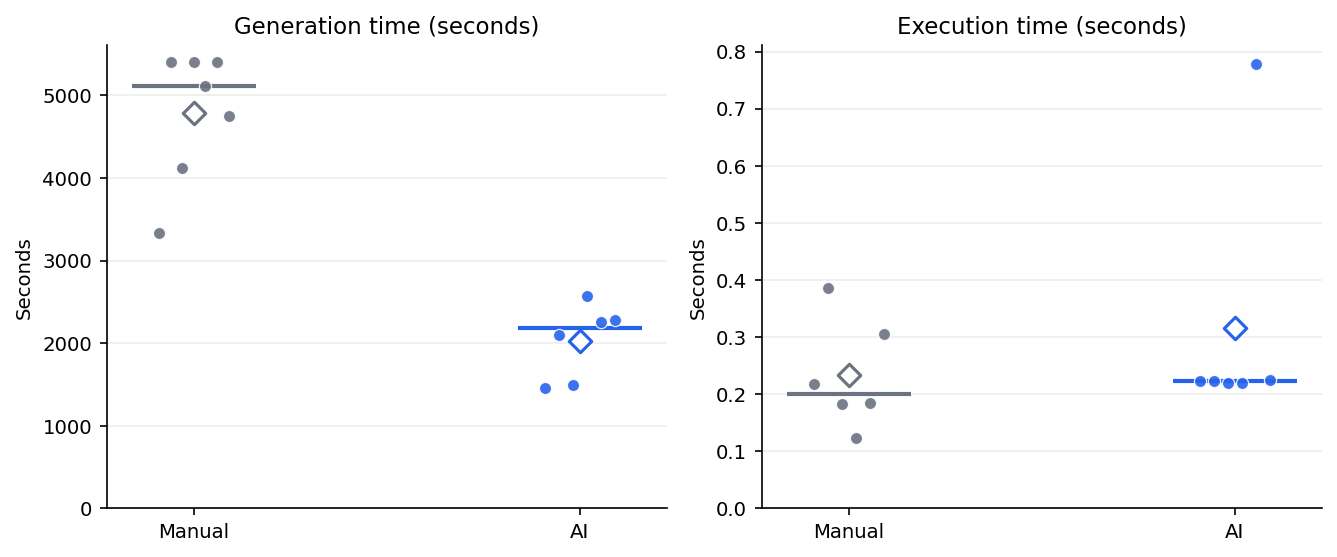

In [9]:
# 时间指标单独展示，避免与效率比值混在一组坐标轴中。
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, metric in zip(axes, EFFICIENCY_METRICS[:2]):
    participant_dot_panel(ax, plot_participants, metric, metric_metadata[metric])
fig.tight_layout()
save_figure(fig, "efficiency_times")
plt.show()
plt.close(fig)

### 图 3. 生成效率与执行效率

第一行为生成效率，第二行为执行效率；列依次为 branch coverage、statement coverage、mutation score。各面板独立缩放。

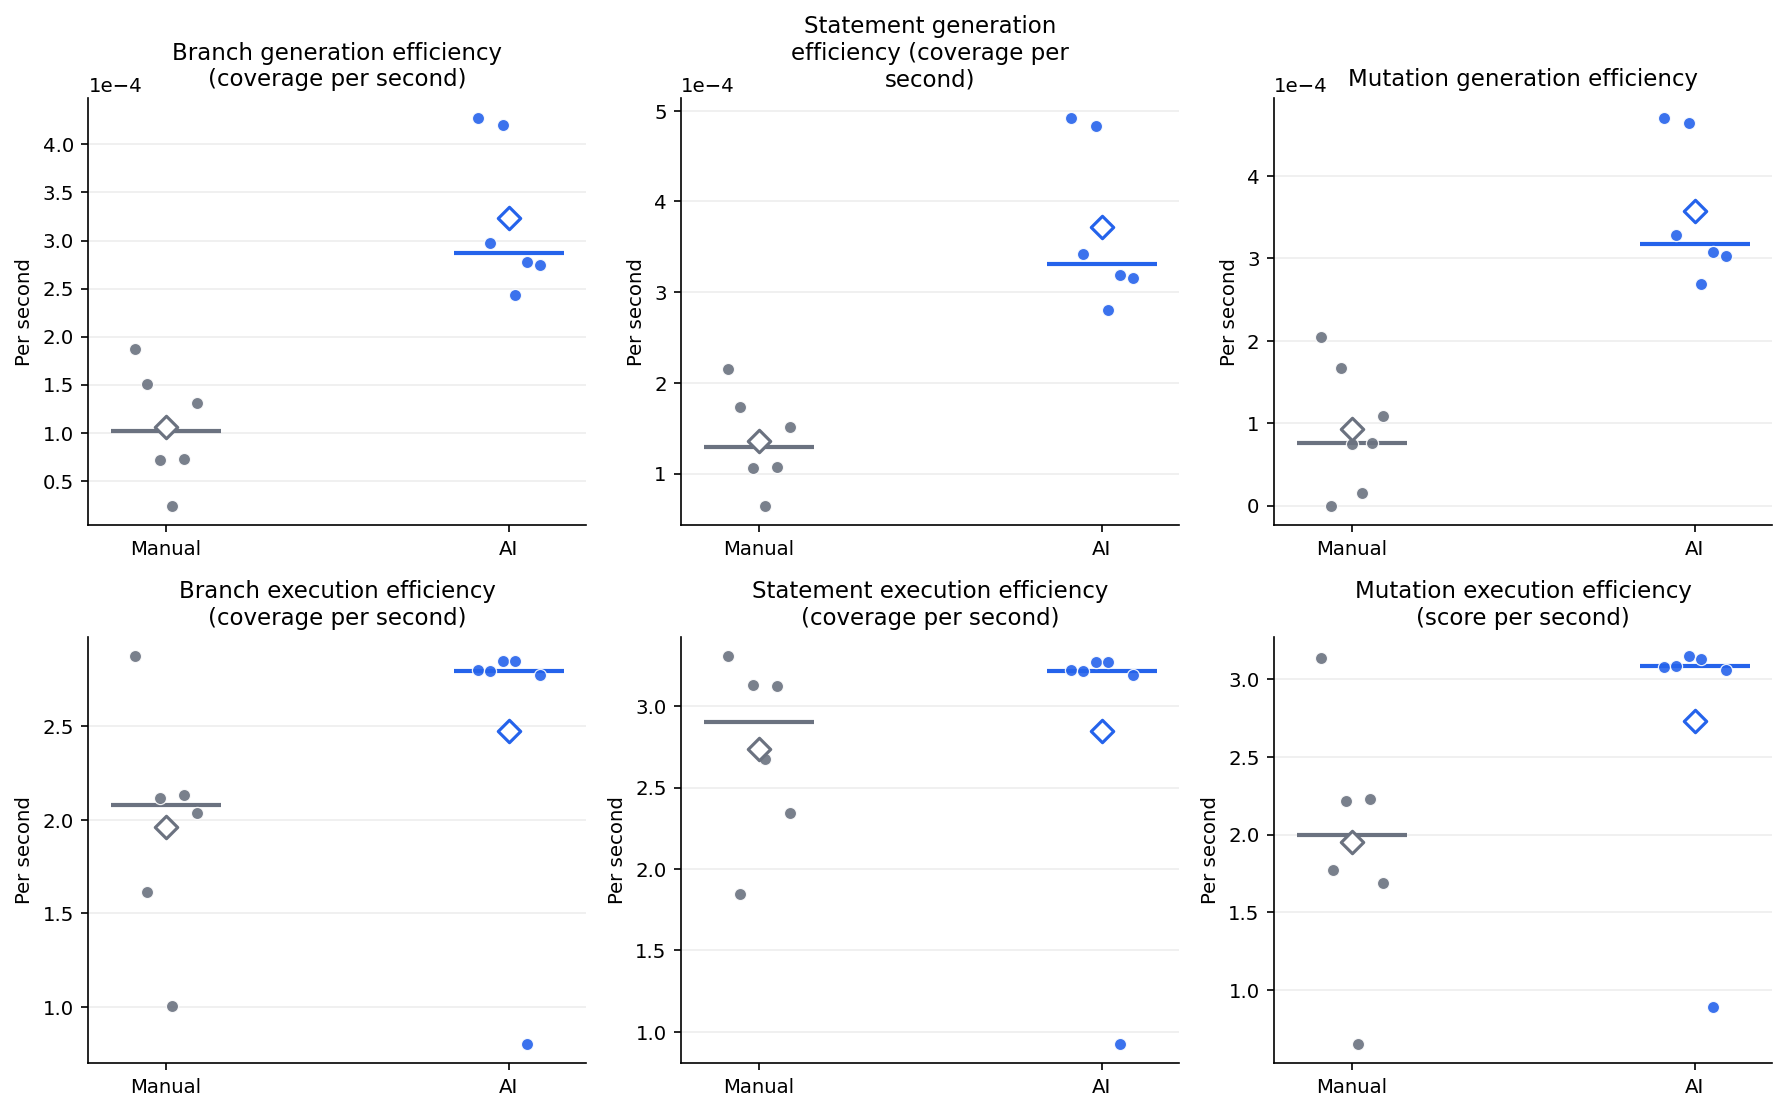

In [10]:
# 六种比值全部展示；需与前面的分子分数、时间和有效样本数一起阅读。
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
for ax, metric in zip(axes.flat, EFFICIENCY_METRICS[2:]):
    participant_dot_panel(ax, plot_participants, metric, metric_metadata[metric])
fig.tight_layout()
save_figure(fig, "efficiency_rates")
plt.show()
plt.close(fig)

### 组间差异与不确定性

蓝点为 AI − Manual 均值差，横线为 95% bootstrap 区间。点上方标注估计值，两端下方标注下限和上限。每个指标使用独立横轴；百分比指标转换为百分点。此图使用统计表的完整样本（含 6 号），与隐藏 6 号的个体图不同。Holm 校正仍针对跨维度的三个预设主要结局。

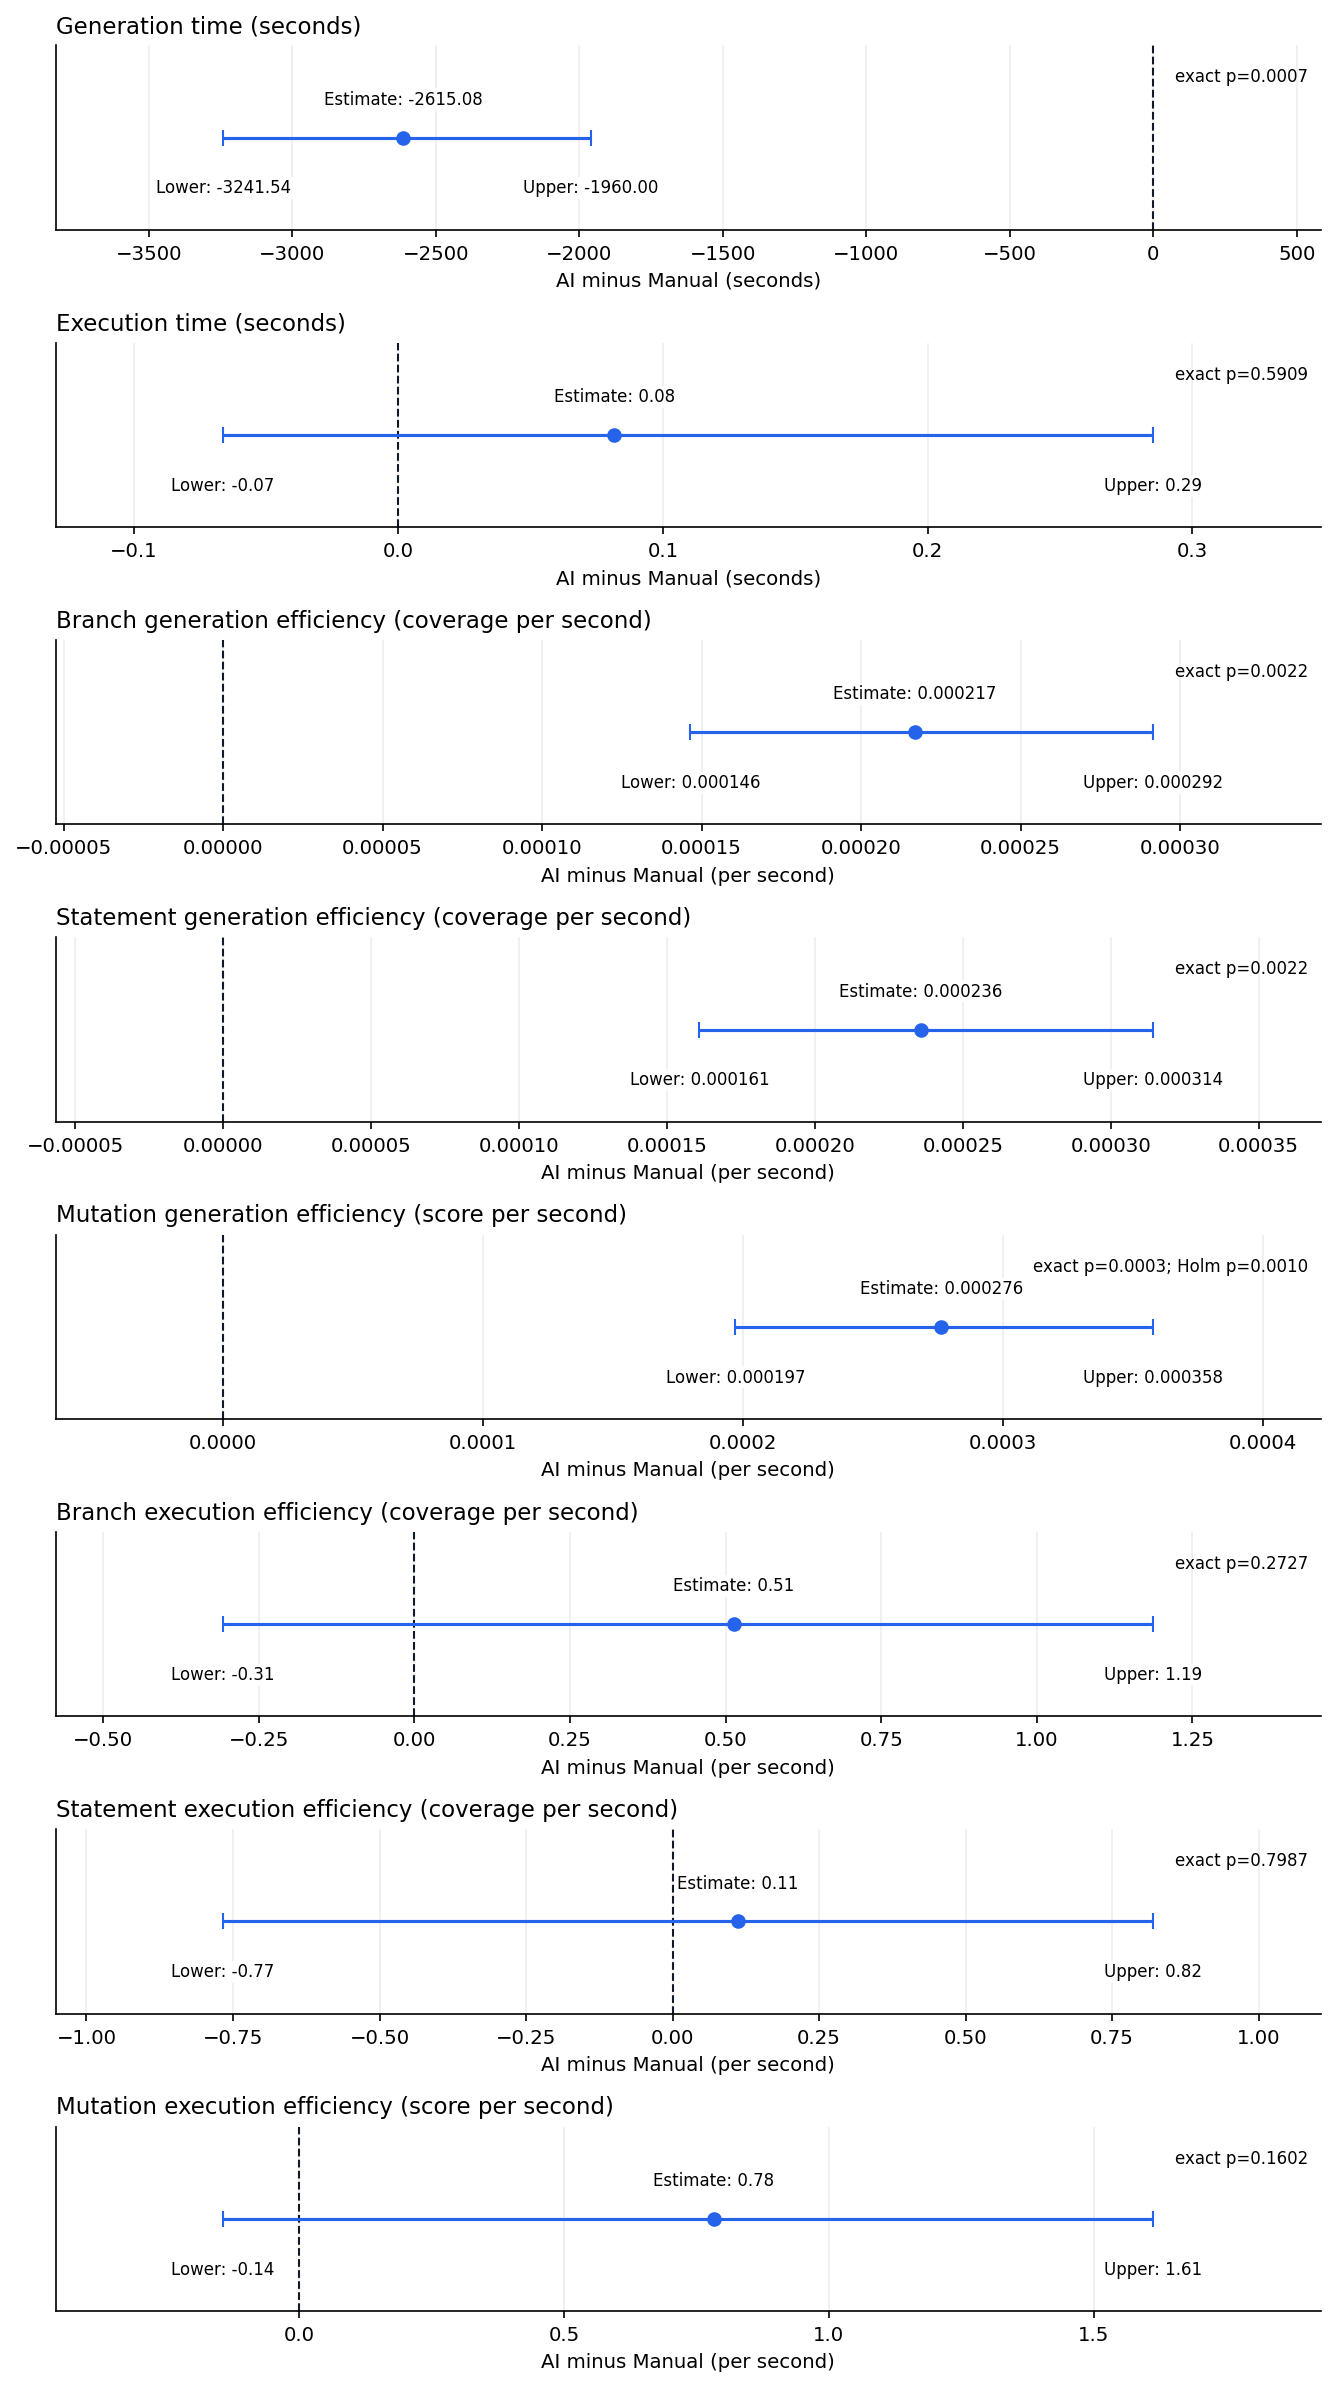

In [11]:
# 独立坐标轴避免比例、秒和每秒速率混在同一尺度。
rows = ordered_results(EFFICIENCY_METRICS)
fig, axes = plt.subplots(len(rows), 1, figsize=(9, 2.0 * len(rows)), squeeze=False)
for ax, (_, row) in zip(axes.flat, rows.iterrows()):
    multiplier = 100.0 if row["scale"] == "proportion" else 1.0
    estimate = row["mean_difference_ai_minus_manual"] * multiplier
    lower = row["bootstrap_ci95_lower"] * multiplier
    upper = row["bootstrap_ci95_upper"] * multiplier
    ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
    ax.errorbar(estimate, 0, xerr=[[estimate - lower], [upper - estimate]],
                fmt="o", color=GROUP_COLORS["AI"], capsize=4)
    # 数字跟随其实际横坐标，估计值置于上方，两个端点置于下方。
    number = lambda value: f"{value:.3g}" if 0 < abs(value) < 0.01 else f"{value:.2f}"
    for value, label, offset in [(estimate, "Estimate", 14), (lower, "Lower", -20), (upper, "Upper", -20)]:
        ax.annotate(f"{label}: {number(value)}", (value, 0),
                    xytext=(0, offset), textcoords="offset points", ha="center",
                    va="bottom" if offset > 0 else "top", fontsize=8,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1))
    ax.set_ylim(-1, 1)
    ax.margins(x=0.18)
    ax.set_yticks([])
    ax.set_title(str(row["label"]), loc="left")
    unit = {"proportion": "percentage points", "seconds": "seconds", "rate": "per second"}[row["scale"]]
    ax.set_xlabel(f"AI minus Manual ({unit})")
    p_text = f"exact p={row['exact_permutation_p_value']:.4f}"
    if pd.notna(row["holm_adjusted_p_value"]):
        p_text += f"; Holm p={row['holm_adjusted_p_value']:.4f}"
    ax.text(0.99, 0.8, p_text, transform=ax.transAxes, ha="right", fontsize=8)
    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "efficiency_difference_intervals")
plt.show()
plt.close(fig)

### 图 4. 生成时间与 mutation effectiveness

结合速度和质量观察个体差异；标签可追溯到参与者数据表。

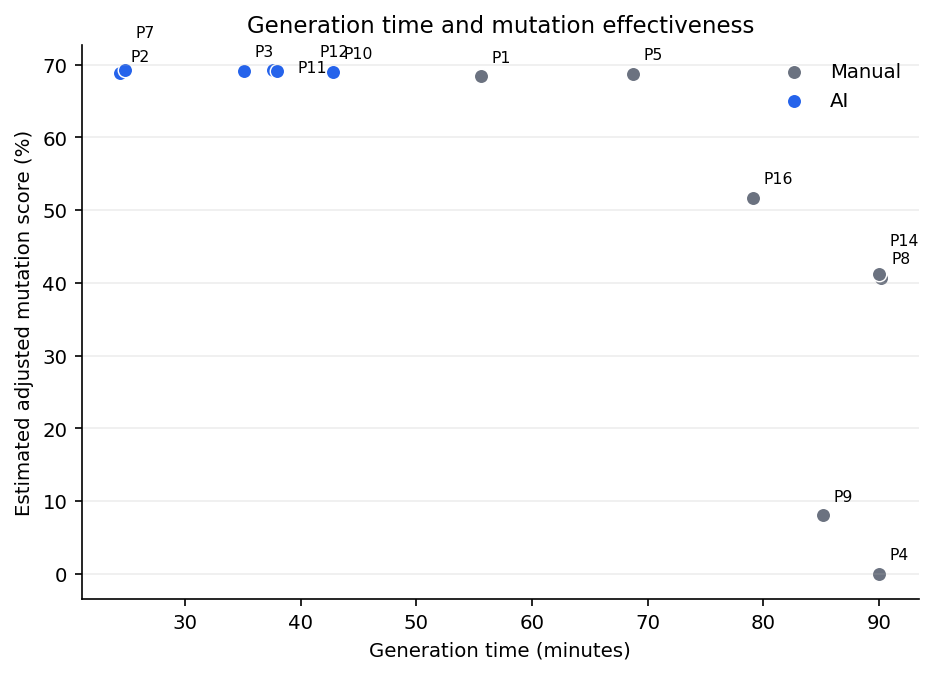

In [12]:
# Participant labels allow possible time-effectiveness trade-offs to be traced to
# the master table without aggregating away individual variation.
label_offsets = {
    1: (5, 7), 2: (5, 6), 3: (5, 7), 4: (5, 7), 5: (5, 7), 6: (5, 7),
    7: (5, 16), 8: (5, 7), 9: (5, 7), 10: (5, 7), 11: (12, -1),
    12: (20, 7), 14: (5, 14), 16: (5, 7),
}
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for group in GROUP_ORDER:
    subset = plot_participants.loc[plot_participants["group"].eq(group)]
    ax.scatter(
        subset["generation_time_seconds"] / 60,
        subset["specified_estimated_adjusted_mutation_score"] * 100,
        s=48, color=GROUP_COLORS[group], edgecolor="white", linewidth=0.7, label=group,
    )
    for _, row in subset.iterrows():
        participant = int(row["participant_number"])
        ax.annotate(
            f"P{participant}",
            (row["generation_time_seconds"] / 60,
             row["specified_estimated_adjusted_mutation_score"] * 100),
            xytext=label_offsets[participant], textcoords="offset points", fontsize=7.5,
        )
ax.set_xlabel("Generation time (minutes)")
ax.set_ylabel("Estimated adjusted mutation score (%)")
ax.set_title("Generation time and mutation effectiveness")
ax.legend(loc="best")
save_figure(fig, "generation_time_vs_mutation")
plt.show()
plt.close(fig)

### 图 5. 执行时间与展开后的测试数量

横轴为对数尺度。参与者 11 的 656 个 pytest items 是需单独审查的高杠杆观测。

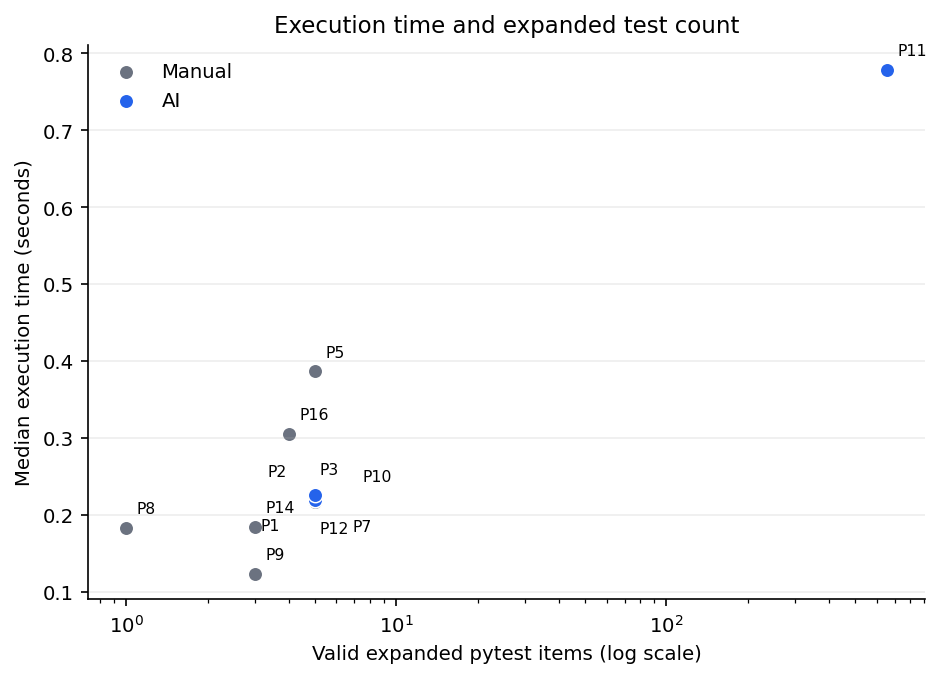

In [13]:
# A log x-axis keeps participant 11's 656 expanded pytest items visible without
# compressing the remaining plot_participants into an unreadable cluster.
execution_data = plot_participants.loc[plot_participants["execution_time_seconds"].notna()].copy()
label_offsets = {
    1: (-26, -14), 2: (-23, 10), 3: (2, 11), 5: (5, 7), 7: (18, -15),
    8: (5, 7), 9: (5, 7), 10: (23, 9), 11: (5, 7), 12: (2, -18),
    14: (5, 7), 16: (5, 7),
}
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for group in GROUP_ORDER:
    subset = execution_data.loc[execution_data["group"].eq(group)]
    ax.scatter(
        subset["valid_test_count"], subset["execution_time_seconds"],
        s=48, color=GROUP_COLORS[group], edgecolor="white", linewidth=0.7, label=group,
    )
    for _, row in subset.iterrows():
        participant = int(row["participant_number"])
        ax.annotate(
            f"P{participant}", (row["valid_test_count"], row["execution_time_seconds"]),
            xytext=label_offsets[participant], textcoords="offset points", fontsize=7.5,
        )
ax.set_xscale("log")
ax.set_xlabel("Valid expanded pytest items (log scale)")
ax.set_ylabel("Median execution time (seconds)")
ax.set_title("Execution time and expanded test count")
ax.legend(loc="best")
save_figure(fig, "execution_time_vs_test_count")
plt.show()
plt.close(fig)

### Efficiency 敏感性分析

检查排除参与者 11 和对时间取对数后，结果是否变化。

In [14]:
display(sensitivity_for(EFFICIENCY_METRICS + ["log_generation_time", "log_execution_time"]))

,scenario,metric,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,permutation_allocations
3,Execution time excluding participant 11,execution_time_seconds,5,6,0.222535,0.233656,-0.011120,-0.085556,0.052915,0.333333,0.809524,462
4,Mutation execution efficiency excluding partic...,mutation_execution_efficiency_per_second,5,6,3.103125,1.951363,1.151762,0.571068,1.755175,0.733333,0.012987,462
5,Log-transformed generation time,log_generation_time,6,8,7.591435,8.426876,-0.835442,-1.051002,-0.625121,-1.000000,0.000333,3003
6,Log-transformed execution time,log_execution_time,6,6,-1.294012,-1.522627,0.228615,-0.197219,0.742811,0.444444,0.452381,924


## 3. Maintainability — 静态可维护性风险

Table 4.1 的指标是 test smell density。当前操作定义为确认的 source-test/smell
配对数 ÷（eligible source tests × 7 种冻结的 smell 定义），数值越低越好。
参与者 4、6 没有有效测试，主要分析保留 NA。类型数量为描述性补充。
Phase 1 的静态结构指标不能直接代表 Phase 2 的真实维护成本。

In [15]:
# 按 Table 4.1 顺序展示参与者数据；NA 保留为缺失，不能当成零。
maintainability_data = participants[["participant_number", "group", "eligible_test_count", "confirmed_pair_count", "uncertain_pair_count", *MAINTAINABILITY_METRICS]].copy()
display(maintainability_data)
# 同一维度内先看描述统计，再看组间比较；保留主要/探索性角色。
display(descriptive.loc[descriptive["metric"].isin(MAINTAINABILITY_METRICS)])
display(ordered_results(MAINTAINABILITY_METRICS))

,participant_number,group,eligible_test_count,confirmed_pair_count,uncertain_pair_count,test_smell_density
0,1,Manual,5.0,2.0,0.0,0.057143
1,2,AI,5.0,1.0,0.0,0.028571
2,3,AI,5.0,1.0,0.0,0.028571
3,4,Manual,0.0,0.0,0.0,NaN
4,5,Manual,5.0,3.0,0.0,0.085714
5,6,Manual,0.0,0.0,0.0,NaN
6,7,AI,5.0,1.0,0.0,0.028571
7,8,Manual,1.0,1.0,0.0,0.142857
8,9,Manual,2.0,4.0,0.0,0.285714
9,10,AI,5.0,1.0,0.0,0.028571


,metric,group,n,mean,standard_deviation,median,first_quartile,third_quartile,minimum,maximum
4,test_smell_density,AI,6,0.033333,0.011664,0.028571,0.028571,0.028571,0.028571,0.057143
5,test_smell_density,Manual,6,0.126984,0.087840,0.114285,0.064286,0.142857,0.047619,0.285714


,metric,label,analysis_role,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,holm_adjusted_p_value,scale
0,test_smell_density,Test smell density,Primary,6,6,0.033333,0.126984,-0.093651,-0.161905,-0.036508,-0.916667,0.006494,0.012987,proportion


### 图 6. Test smell density 个体分布

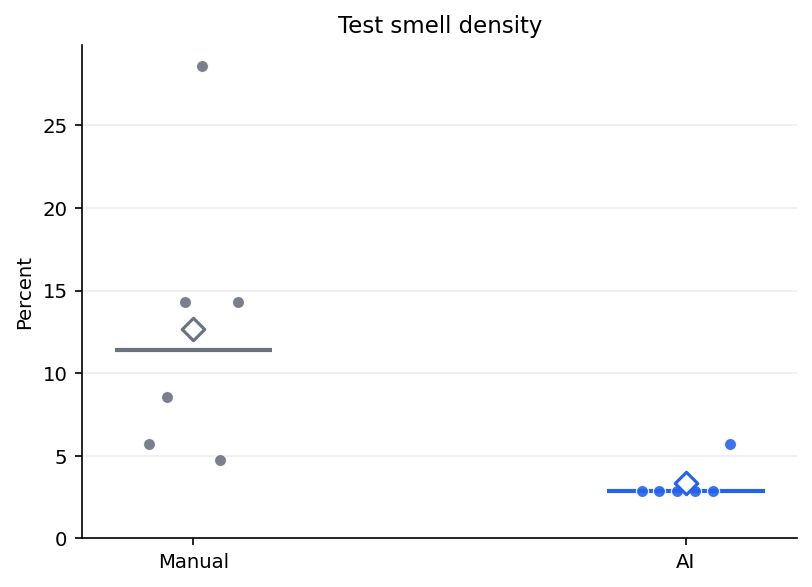

In [16]:
# 分母是源测试函数和七种 smell 类型，不是展开后的 pytest item 数。
fig, ax = plt.subplots(figsize=(5.5, 4))
participant_dot_panel(ax, plot_participants, "test_smell_density", metric_metadata["test_smell_density"])
fig.tight_layout()
save_figure(fig, "maintainability_density")
plt.show()
plt.close(fig)

### 组间差异与不确定性

蓝点为 AI − Manual 均值差，横线为 95% bootstrap 区间。点上方标注估计值，两端下方标注下限和上限。每个指标使用独立横轴；百分比指标转换为百分点。此图使用统计表的完整样本（含 6 号），与隐藏 6 号的个体图不同。Holm 校正仍针对跨维度的三个预设主要结局。

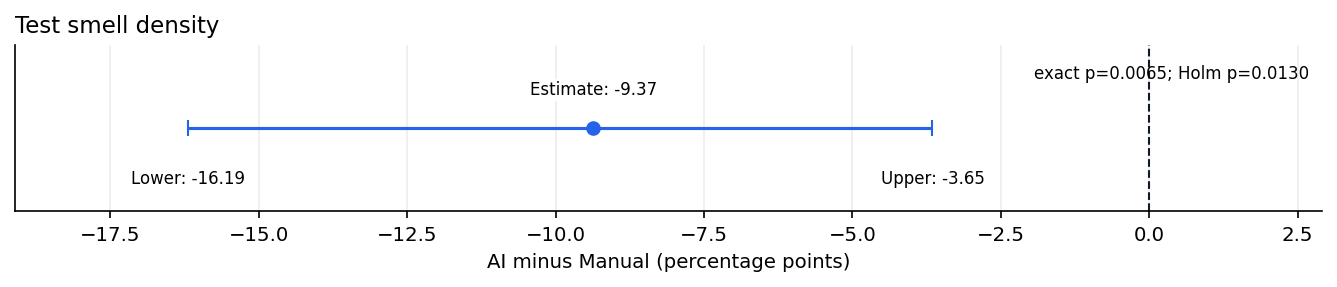

In [17]:
# 独立坐标轴避免比例、秒和每秒速率混在同一尺度。
rows = ordered_results(MAINTAINABILITY_METRICS)
fig, axes = plt.subplots(len(rows), 1, figsize=(9, 2.0 * len(rows)), squeeze=False)
for ax, (_, row) in zip(axes.flat, rows.iterrows()):
    multiplier = 100.0 if row["scale"] == "proportion" else 1.0
    estimate = row["mean_difference_ai_minus_manual"] * multiplier
    lower = row["bootstrap_ci95_lower"] * multiplier
    upper = row["bootstrap_ci95_upper"] * multiplier
    ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
    ax.errorbar(estimate, 0, xerr=[[estimate - lower], [upper - estimate]],
                fmt="o", color=GROUP_COLORS["AI"], capsize=4)
    # 数字跟随其实际横坐标，估计值置于上方，两个端点置于下方。
    number = lambda value: f"{value:.3g}" if 0 < abs(value) < 0.01 else f"{value:.2f}"
    for value, label, offset in [(estimate, "Estimate", 14), (lower, "Lower", -20), (upper, "Upper", -20)]:
        ax.annotate(f"{label}: {number(value)}", (value, 0),
                    xytext=(0, offset), textcoords="offset points", ha="center",
                    va="bottom" if offset > 0 else "top", fontsize=8,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1))
    ax.set_ylim(-1, 1)
    ax.margins(x=0.18)
    ax.set_yticks([])
    ax.set_title(str(row["label"]), loc="left")
    unit = {"proportion": "percentage points", "seconds": "seconds", "rate": "per second"}[row["scale"]]
    ax.set_xlabel(f"AI minus Manual ({unit})")
    p_text = f"exact p={row['exact_permutation_p_value']:.4f}"
    if pd.notna(row["holm_adjusted_p_value"]):
        p_text += f"; Holm p={row['holm_adjusted_p_value']:.4f}"
    ax.text(0.99, 0.8, p_text, transform=ax.transAxes, ha="right", fontsize=8)
    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "maintainability_difference_intervals")
plt.show()
plt.close(fig)

### 图 7. 各类 test smell 的确认数量

汇总全体参与者的配对数，不是实验组间的因果比较。

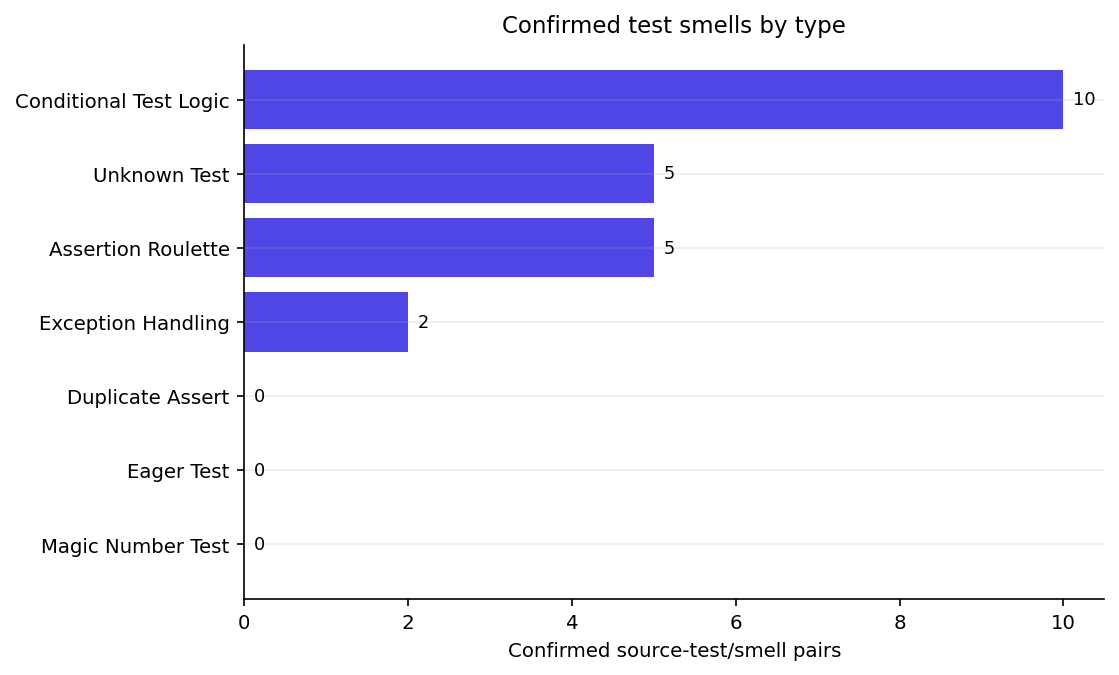

In [18]:
# Counts follow the seven frozen Phase 1 smell definitions. Sorting supports a
# clear ranking; the chart does not replace the density-based primary endpoint.
smell_columns = {
    "assertion_roulette_count": "Assertion Roulette",
    "magic_number_test_count": "Magic Number Test",
    "unknown_test_count": "Unknown Test",
    "conditional_test_logic_count": "Conditional Test Logic",
    "eager_test_count": "Eager Test",
    "duplicate_assert_count": "Duplicate Assert",
    "exception_handling_count": "Exception Handling",
}
smell_totals = plot_participants[list(smell_columns)].sum().rename(index=smell_columns).sort_values()
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.barh(smell_totals.index, smell_totals.values, color="#4F46E5")
ax.set_xlabel("Confirmed source-test/smell pairs")
ax.set_title("Confirmed test smells by type")
ax.set_xlim(left=0)
for y, value in enumerate(smell_totals.values):
    ax.text(value + 0.12, y, f"{int(value)}", va="center", fontsize=8.5)
save_figure(fig, "test_smell_types")
plt.show()
plt.close(fig)

### Maintainability 敏感性分析

将无有效测试的提交极端地赋值为 density = 1，仅用于压力测试，不替代主要完整案例结果。

In [19]:
display(sensitivity_for(MAINTAINABILITY_METRICS))

,scenario,metric,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,permutation_allocations
2,No-valid-test suites assigned smell density 1,test_smell_density,6,8,0.033333,0.345238,-0.311905,-0.621429,-0.07381,-0.9375,0.068598,3003


## 4. Questionnaire — 背景与主观体验

先展示 pre-survey 背景摘要，再分别展示 AI 和 Manual post-survey 图表。
两版 post-survey 的题目不同，不直接比较同一数字分数，也不合并为未经验证的量表。
开放式回答保留人工编码列；当前不自动推断主题。

### 4.1 Pre-survey 背景摘要

对应 Table 4.1 的部分背景协变量；此处仅作描述，未据此调整组间结果。

In [20]:
display(baseline)

,item,group,n,median,first_quartile,third_quartile
0,How would you rate your English proficiency fo...,AI,6,5.0,3.50,5.00
1,How would you rate your English proficiency fo...,Manual,8,4.0,3.00,4.25
2,How would you rate your overall proficiency in...,AI,6,3.0,2.25,3.00
3,How would you rate your overall proficiency in...,Manual,8,3.0,2.00,3.00
4,How would you rate your overall proficiency in...,AI,6,3.5,2.25,4.00
5,How would you rate your overall proficiency in...,Manual,8,2.5,1.75,3.00
6,How would you rate your overall proficiency in...,AI,6,2.5,1.25,3.75
7,How would you rate your overall proficiency in...,Manual,8,2.0,1.75,3.00
8,How would you rate your experience in pytest?,AI,6,1.5,0.25,2.00
9,How would you rate your experience in pytest?,Manual,8,2.0,0.75,2.25


### 4.2 Post-survey 题目统计

In [21]:
display(likert[["survey", "item_order", "item", "n", "median", "first_quartile", "third_quartile"]])

,survey,item_order,item,n,median,first_quartile,third_quartile
0,AI post-survey,1,Using GitHub Copilot allowed me to complete th...,6,5.0,5.00,5.00
1,AI post-survey,2,Using GitHub Copilot helped me achieve better ...,6,3.5,3.00,4.00
2,AI post-survey,3,"Overall, I found GitHub Copilot to be a useful...",6,5.0,5.00,5.00
3,AI post-survey,4,"In practice, Copilot accurately captured the i...",6,4.0,4.00,4.75
4,AI post-survey,5,The test cases generated by Copilot were mostl...,6,4.5,4.00,5.00
5,AI post-survey,6,"Copilot frequently generated ""hallucinated"" as...",6,2.0,1.25,2.00
6,AI post-survey,7,I was able to write effective comments or prom...,6,4.0,4.00,4.75
7,AI post-survey,8,I was able to accurately identify flaws or inv...,6,4.0,3.25,4.00
8,AI post-survey,9,I was able to effectively adapt my testing wor...,6,4.5,4.00,5.00
9,Manual post-survey,1,(1) I was able to create tests that meaningful...,8,3.0,3.00,4.00


### 图 8. AI post-survey Likert 分布

每行一道题，色块表示 1–5 分回答比例。负向题需按题意解释。

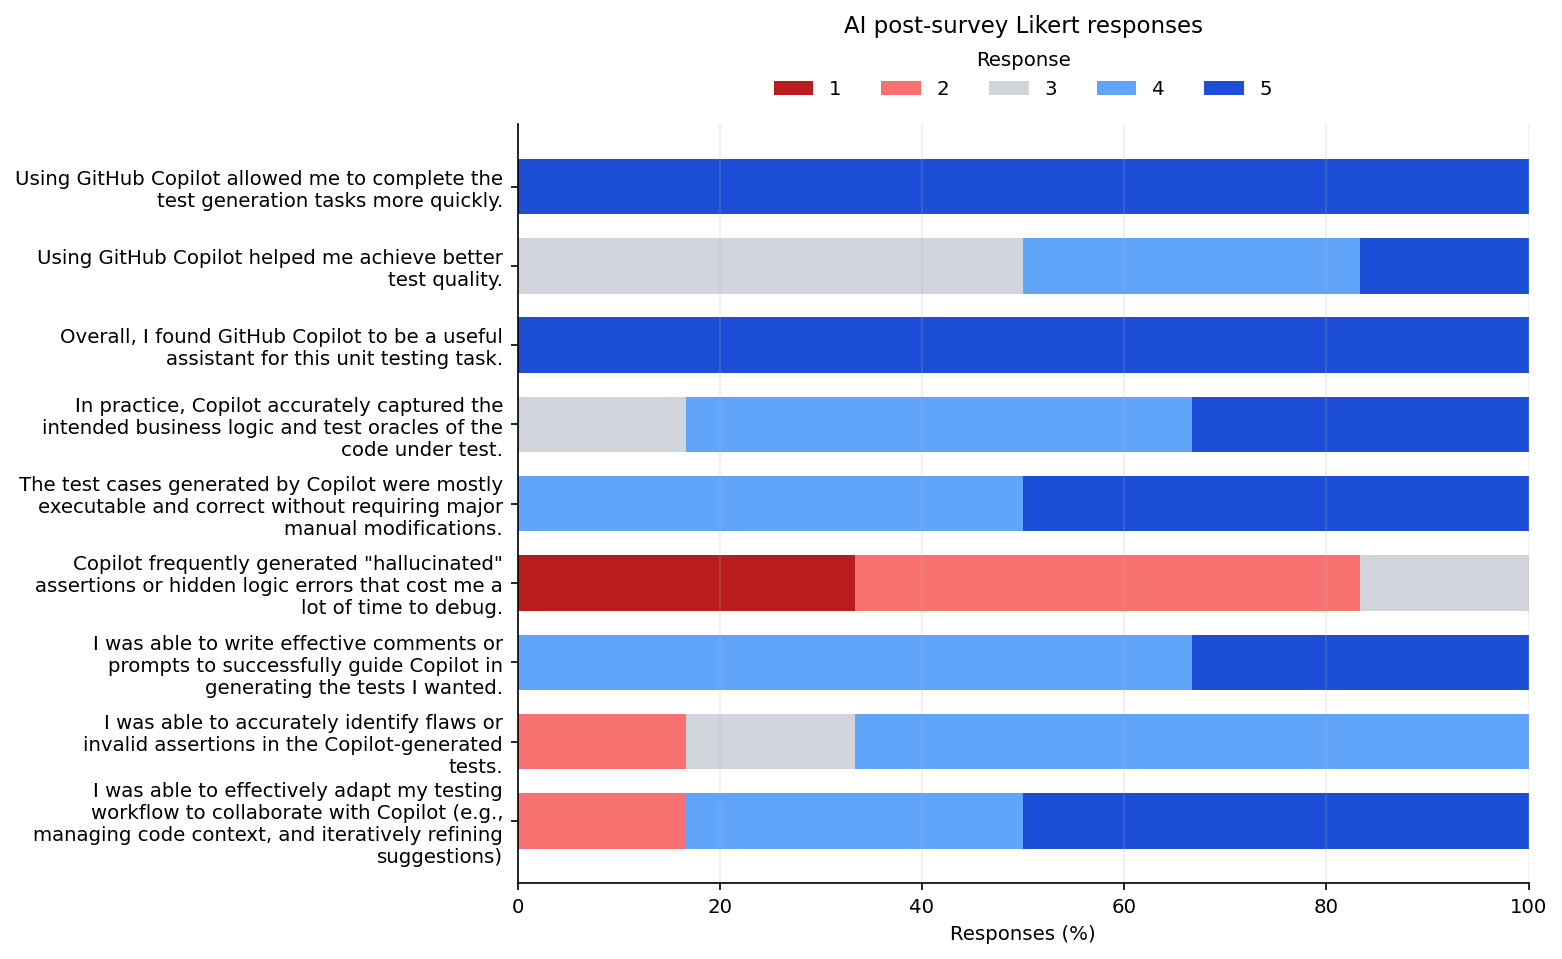

In [22]:
# Items are kept separate rather than combined into an unvalidated composite.
survey_name = "AI post-survey"
survey_data = likert.loc[likert["survey"].eq(survey_name)].sort_values("item_order")
labels = [fill(str(item), width=48) for item in survey_data["item"]]
colors = ["#B91C1C", "#F87171", "#D1D5DB", "#60A5FA", "#1D4ED8"]
fig, ax = plt.subplots(figsize=(10.5, max(5.5, len(survey_data) * 0.72)))
left = np.zeros(len(survey_data))
for score, color in zip(range(1, 6), colors):
    values = survey_data[f"score_{score}_percent"].to_numpy(dtype=float)
    ax.barh(labels, values, left=left, color=color, label=str(score), height=0.7)
    left += values
ax.set_xlim(0, 100)
ax.set_xlabel("Responses (%)")
ax.set_title(f"{survey_name} Likert responses", pad=44)
ax.legend(title="Response", ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.01))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "likert_ai_post")
plt.show()
plt.close(fig)

### 图 9. Manual post-survey Likert 分布

颜色与 AI 版一致，但题目内容不同，应分别解读。

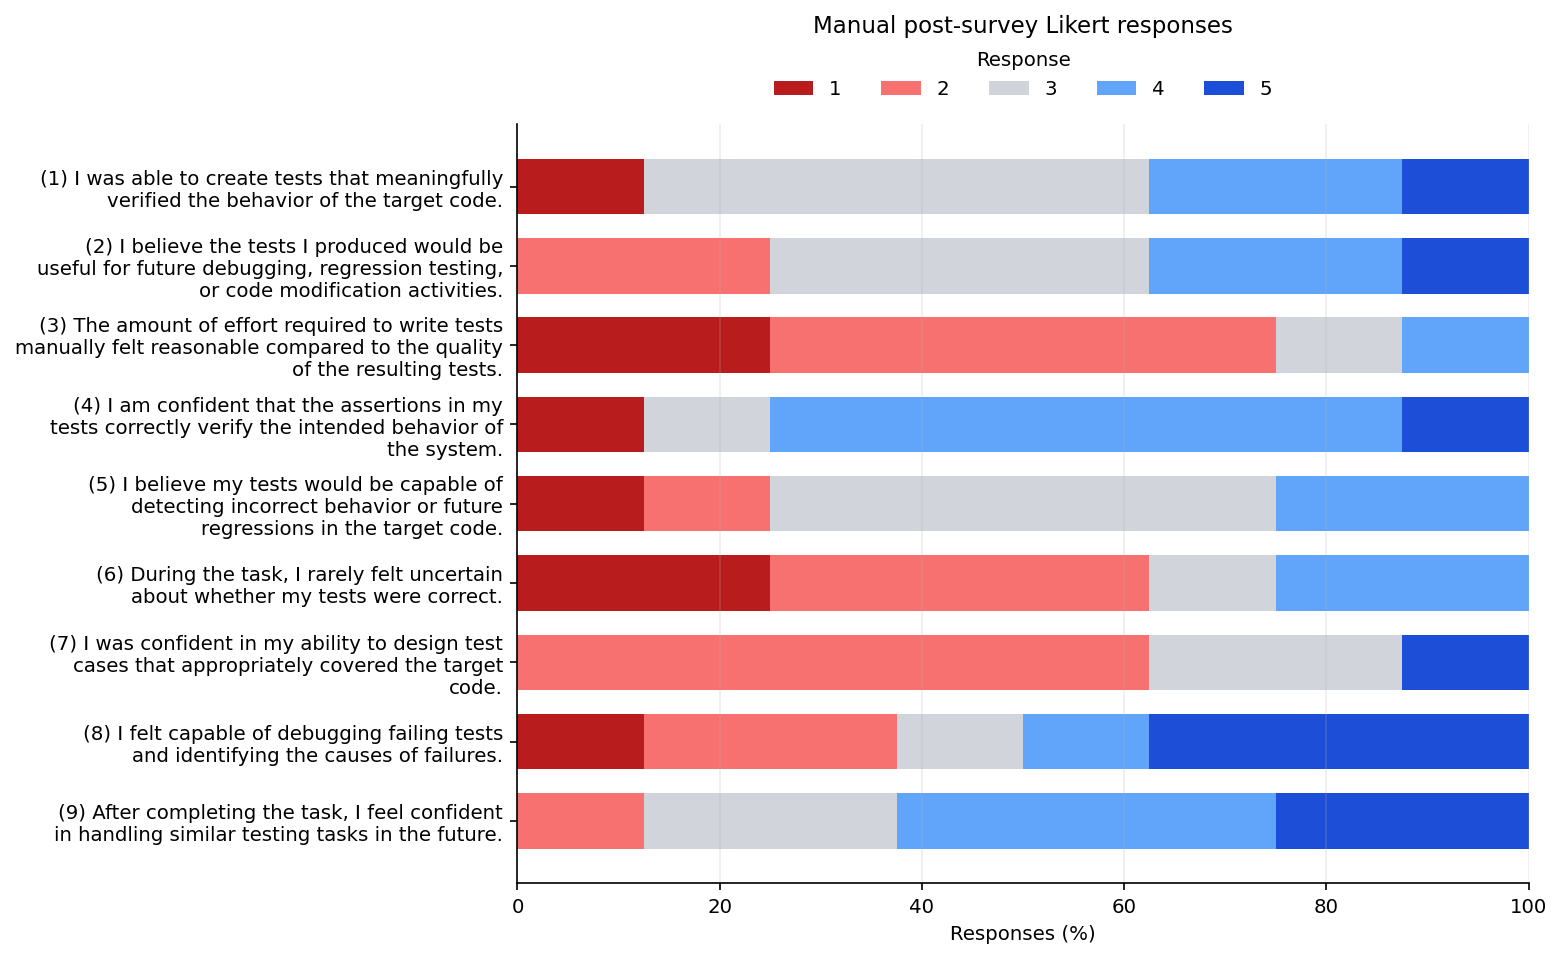

In [23]:
# This survey is plotted independently because its questions differ from the AI
# version; matching colors encode response categories, not comparable constructs.
survey_name = "Manual post-survey"
survey_data = likert.loc[likert["survey"].eq(survey_name)].sort_values("item_order")
labels = [fill(str(item), width=48) for item in survey_data["item"]]
colors = ["#B91C1C", "#F87171", "#D1D5DB", "#60A5FA", "#1D4ED8"]
fig, ax = plt.subplots(figsize=(10.5, max(5.5, len(survey_data) * 0.72)))
left = np.zeros(len(survey_data))
for score, color in zip(range(1, 6), colors):
    values = survey_data[f"score_{score}_percent"].to_numpy(dtype=float)
    ax.barh(labels, values, left=left, color=color, label=str(score), height=0.7)
    left += values
ax.set_xlim(0, 100)
ax.set_xlabel("Responses (%)")
ax.set_title(f"{survey_name} Likert responses", pad=44)
ax.legend(title="Response", ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.01))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "likert_manual_post")
plt.show()
plt.close(fig)

### 4.3 开放式回答与解释边界

以下表保留人工主题编码位置。缺少随机分配记录，结果解释为当前 Phase 1 样本的组间差异；长期维护和 crossover 结论需 Phase 2 数据。

In [24]:
display(open_text)

,survey,group,participant_number,question,response,theme_codes,coding_notes
0,AI post-survey,AI,2,What did you find surprisingly helpful about C...,It derictly edits and inserts the generated co...,NaN,NaN
1,AI post-survey,AI,2,"Please describe any challenges, limitations, o...",When I didn't specify the test code shoud foll...,NaN,NaN
2,AI post-survey,AI,7,What did you find surprisingly helpful about C...,its ability to write high quality testing code...,NaN,NaN
3,AI post-survey,AI,7,"Please describe any challenges, limitations, o...",I didn't see any bug challanges in this chatbo...,NaN,NaN
4,AI post-survey,AI,7,"Do you have any other comments, feedback, or s...",All the best,NaN,NaN
5,AI post-survey,AI,10,What did you find surprisingly helpful about C...,The ability to read comments and adapt these t...,NaN,NaN
6,AI post-survey,AI,10,"Please describe any challenges, limitations, o...","If a test gave an error, it was generally easy...",NaN,NaN
7,AI post-survey,AI,11,What did you find surprisingly helpful about C...,actually produced code that fulfilled requirem...,NaN,NaN
8,AI post-survey,AI,11,"Please describe any challenges, limitations, o...",only thing that may be challenging is that did...,NaN,NaN
9,AI post-survey,AI,11,"Do you have any other comments, feedback, or s...",no :),NaN,NaN
